# Extract the relevant information from the files and apply corrections part by part

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tables as tb
from matplotlib import colors

from typing          import Optional
from typing          import Union
from typing          import Callable

from concurrent.futures import ProcessPoolExecutor, as_completed
from functools          import partial

import sys,os,os.path
from pathlib import Path
sys.path.append("/gluster/data/next/software/IC_311024/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
sys.path.append("/gluster/data/next/notebooks/")
os.environ['ICTDIR']='/gluster/data/next/software/IC_311024/'

from invisible_cities.io.dst_io           import load_dst, load_dsts, df_writer
from invisible_cities.io.hits_io          import hits_writer
from invisible_cities.core                import tbl_functions   as tbl
from invisible_cities.core.core_functions import in_range
#from invisible_cities.cities.beersheba    import hitc_to_df_
from invisible_cities.io.hits_io          import hits_from_df
from invisible_cities.evm.nh5             import HitsTable
from invisible_cities.types.symbols       import NormStrategy
from invisible_cities.types.symbols       import NormMethod
from invisible_cities.types.ic_types      import NoneType
from invisible_cities.reco.corrections    import read_maps, get_df_to_z_converter, apply_all_correction
from invisible_cities.evm.event_model     import HitCollection



from tqdm import tqdm


from john_books.year_of_horse_notebooks.MC_validator import functions_HE as func

In [2]:
from scipy.interpolate import interp1d
from scipy.interpolate import griddata

def get_corr3d(fname, method):
    if (method == 'maria'):
        krmap = pd.read_hdf(fname)
        krmap = krmap[~krmap.mu.isna()] # replace e0 by the corresponding column
        krmap['factor'] = krmap.mu.values
        dtxy_map   = krmap.loc[:, ['dt', 'x', 'y']].values
    elif (method == 'LT'):
        krmap = pd.read_hdf(fname, '/krmap')
        krmap = krmap[~krmap.e0.isna()] # replace e0 by the corresponding column
        dtxy_map   = krmap.loc[:, list('zyx')].values
    elif (method == '202602'):
        krmap = pd.read_hdf(fname, '/krmap')
        krmap = krmap[~krmap.e0.isna()] # replace e0 by the corresponding column
        krmap['factor'] = krmap.e0.values
        dtxy_map   = krmap.loc[:, list('zyx')].values

    factor_map = krmap.factor.values
    def corr(dt, x, y, method="nearest"):
        dtxy_data   = np.stack([dt, x, y], axis=1)
        factor_data = griddata(dtxy_map, factor_map, dtxy_data, method=method)
        return factor_data
    return corr
  
def smooth(y, n=4):
    m  = len(y)
    yf = np.flip(y)
    y  = np.concatenate([yf, y, yf])
    z  = np.ones(n) / n
    y  = np.convolve(y, z, mode="same")
    return y[m:2*m]

def get_corrt(fname, n=4):
    time_data = pd.read_hdf(fname, "/data")
    smoothed  = smooth(time_data.e0, n)
    corr      = smoothed.min() / smoothed
    time_correction = interp1d(time_data.time,  corr, "cubic", bounds_error=False, fill_value=(corr[0], corr[-1]))
    return time_correction
  




In [3]:
# maps
maria_map  = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/MC_3Dmap_median.h5'
MC_from_LT = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/' + 'MC_from_LT_202602.map3d'
MC_2026    = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/' + 'MC_202602.map3d'

In [4]:
def apply_corrections_and_save(input_path, output_path, corr_map, corr_map_str):
    '''
    quick function that takes a file, applies the corrections and outputs
    another file with the corrected info
    '''

    # read in the file
    data = load_dst(input_path, 'RECO', 'Events')

    # produce corr_map
    corr3d = get_corr3d(corr_map, corr_map_str)

    data['Ec'] = data.E * corr3d([0],[0],[0]) / corr3d(data.Z, data.X, data.Y)

    # save the relevant shit out
    trimmed_data = data[['event', 'E', 'Ec', 'Z', 'X', 'Y']]
    trimmed_data.to_hdf(output_path, key = 'RECO/Events', mode='w', complevel = 5, complib='blosc:lz4')



In [5]:
# collect all files
n100_dir = '/gluster/data/next/files/TOPOLOGY_John/MC_data/sophronia_lowth/'
file_names = [f for f in os.listdir(n100_dir) if f.endswith('.h5')]
file_paths = [os.path.join(n100_dir, f) for f in file_names]

In [6]:
# marias corrections first
maria_output_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/sophronia_lowth_corr_maria/'
output_paths = [os.path.join(maria_output_path, f) for f in file_names]


In [ ]:
number_of_files = 20
# parallelise
def apply_corrections_pair(paths, corr_map, corr_map_str):
    input_path, output_path = paths
    apply_corrections_and_save(input_path, output_path, corr_map, corr_map_str)

with ProcessPoolExecutor(max_workers=4) as executor:
    fn = partial(apply_corrections_pair, corr_map = maria_map, corr_map_str = 'maria')
    futures = list(executor.map(fn, zip(file_paths[:number_of_files], output_paths[:number_of_files])))

In [7]:
import traceback

def load_single_file(file_path):
    '''
    Load data from a single h5 file and produce dataframes for /Tracking/Tracks

    Args:
        file_path       :       str
                                Path to the h5 file to be loaded.

    Returns:
        tracks_df       :       pandas.DataFrame
                                DataFrame containing the /Tracking/Tracks data.
        failed          :       int
                                1 if the file failed to load, 0 otherwise.
    '''
    try: 
        tracks_df = pd.read_hdf(file_path, key='RECO/Events') 
        return tracks_df, 0
    except Exception as e:
        print(f'File {file_path} broke with error:\n{e}')
        x = pd.DataFrame()
        return x, 1

def load_data_fast(folder_path):
    '''
    Load multiple h5 files and produce concatenated dataframes for /Tracking/Tracks, /MC/Particles, and their corresponding eventmap.

    Args:
        folder_path     :       str
                                Path to the folder containing the h5 files.

    Returns:
        tracks          :       pandas.DataFrame
                                Concatenated DataFrame containing the /Tracking/Tracks data from all h5 files.
        total_failures  :       int
                                Total number of failed file loads.
    '''
    try:
        file_names = [f for f in os.listdir(folder_path) if f.endswith('.h5')]
        file_paths = [os.path.join(folder_path, f) for f in file_names][:5]

        with ProcessPoolExecutor() as executor:
            results = list(executor.map(load_single_file, file_paths))

        # Separate the results into respective lists
        tracks_list, failures = zip(*results)

        tracks = pd.concat(tracks_list, axis=0, ignore_index=True)

        # Sum up the failures
        total_failures = sum(failures)

        return tracks, total_failures
    except Exception as e:
        print(f"An error occurred: {e}")
        traceback.print_exc()


In [8]:
holder, err = load_data_fast(maria_output_path)

In [9]:
display(holder)

,event,E,Ec,Z,X,Y
0,7000000,0.0,0.0,959.250799,-486.125,-296.825
1,7000000,0.0,0.0,959.250799,-486.125,-281.275
2,7000000,0.0,0.0,959.250799,-486.125,-265.725
3,7000000,0.0,0.0,959.250799,-486.125,-250.175
4,7000000,0.0,0.0,959.250799,-486.125,-234.625
...,...,...,...,...,...,...
104276978,29200160,0.0,0.0,764.912156,493.525,247.425
104276979,29200160,0.0,0.0,764.912156,493.525,262.975
104276980,29200160,0.0,0.0,764.912156,493.525,278.525
104276981,29200160,0.0,0.0,764.912156,493.525,294.075


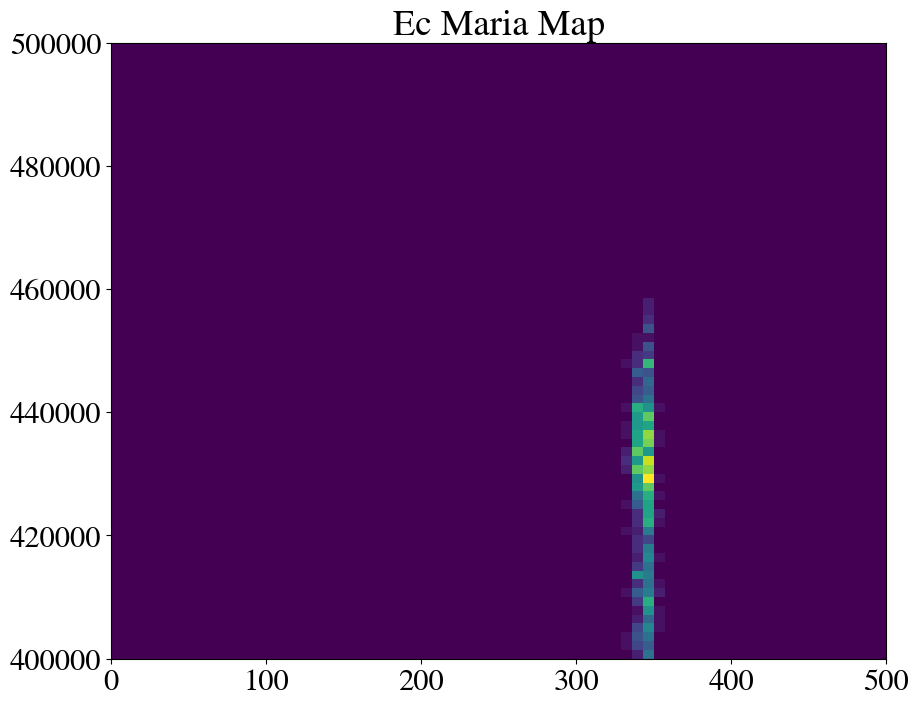

In [12]:
# plot
holder['R'] = (holder['X']**2 + holder['Y']**2)**0.5
events = holder.groupby("event").agg(dict(Ec="sum", R="mean", Z="mean"))


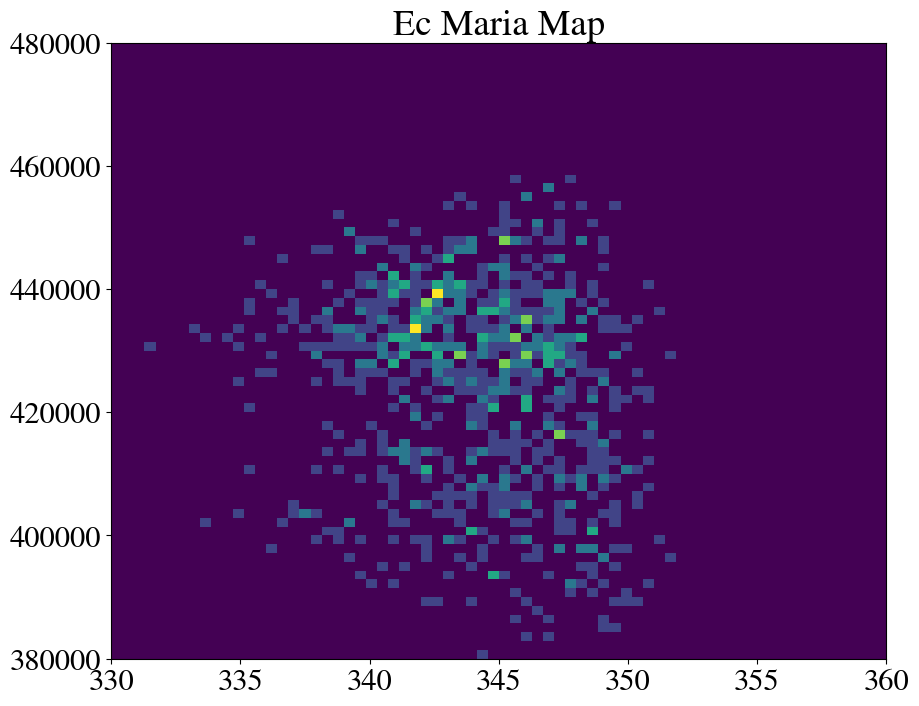

In [19]:

plt.hist2d(events.R, events.Ec, bins = 70, range = [[330, 360], [380000, 480000]])#, range = [[0, 500], [400000, 500000]])# range = [[0, 500],[0, 0.01]], bins = 70)
plt.title('Ec Maria Map')
plt.show()

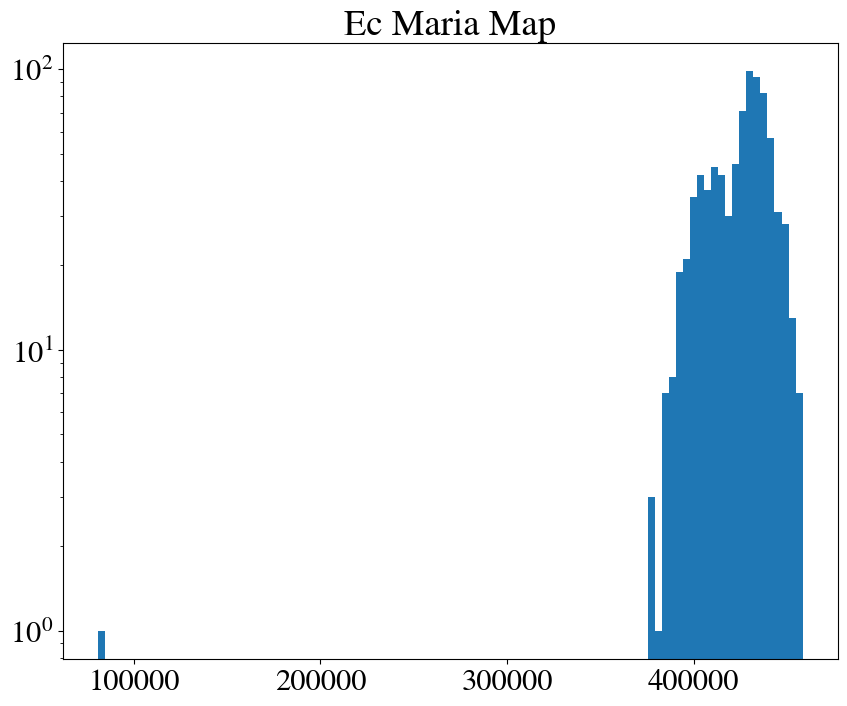

In [20]:
plt.hist(events.Ec, bins = 100)
plt.yscale('log')
plt.title('Ec Maria Map')
plt.show()

In [21]:
# convert into keV
def normalization(krmap    : pd.DataFrame,
                  method   : NormMethod,
                  xy_params : dict = None) -> float:
    """
    Given a input krypton map, normalizes the whole map to a certain value
    as a function of the chosen method.
    Parameters
    ----------
    krmap : pd.DataFrame
      Input krypton map whose bins are going to be normalized.
    method : NormMethod
      Method for normalization, defined in class function NormMethod.
    xy_params : dict
      Limits in x and y that define the region inside of which the normalization
      will be performed.
    Returns
    -------
    Normalization value using the chosen method.
    """

    krmap = krmap.dropna(subset=['mu'])

    anode = krmap[krmap.k == 0]

    if method is NormMethod.maximum:
        E_reference_max = krmap.mu.max()
        return E_reference_max

    if method is NormMethod.mean_chamber:
        E_reference_chamber = krmap.mu.mean()
        return E_reference_chamber

    if method is NormMethod.median_chamber:
        E_median_chamber = krmap.mu.median()
        return E_median_chamber

    if method is NormMethod.mean_anode:
        E_reference_anode = anode.mu.mean()
        return E_reference_anode

    if method is NormMethod.median_anode:
        E_median_anode = anode.mu.median()
        return E_median_anode

    mask_region = ( in_range(krmap.x, xy_params['x_low'], xy_params['x_high']) &
                    in_range(krmap.y, xy_params['y_low'], xy_params['y_high'])
                   ).values

    krmap = krmap[mask_region]

    if method is NormMethod.mean_region_chamber:
        E_reference_region = krmap.mu.mean()
        return E_reference_region

    if method is NormMethod.median_region_chamber:
        E_median_region = krmap.mu.median()
        return E_median_region

    anode = krmap[krmap.k == 0]

    if method is NormMethod.mean_region_anode:
        E_reference_slice_anode = anode.mu.mean()
        return E_reference_slice_anode

    if method is NormMethod.median_region_anode:
        E_median_region_anode = anode.mu.median()
        return E_median_region_anode


NameError: name 'NormMethod' is not defined